# Housing Classification

## Problem Statement
The objective is to predict whether a property belongs to the **expensive segment** (`Expensive = 1`) based on available housing attributes.

This classification task can support **early-stage screening decisions** (e.g., prioritising premium listings, directing valuation effort, or flagging higher-value properties for review).

### Decision perspective (cost of errors)
In many screening settings, **false negatives** (expensive properties misclassified as non-expensive) are more costly than false positives because they can lead to missed opportunities or under-prioritisation.  
This motivates evaluating models with metrics beyond accuracy and considering probability thresholds.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec 
from matplotlib.patches import Patch
from scipy import stats
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import pointbiserialr

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

url = "https://drive.google.com/file/d/1qjVXQDkmYlnMPFFx8pTTeAQuH646KVWu/view?usp=share_link"
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]
data = df = pd.read_csv(path)
source = "google drive url fallback"

print("Loaded from:", source)
print("Shape:", df.shape)
display(df.head(10))

Loaded from: google drive url fallback
Shape: (1460, 81)


,LotArea,LotFrontage,TotalBsmtSF,BedroomAbvGr,Fireplaces,PoolArea,GarageCars,WoodDeckSF,ScreenPorch,Expensive,MSZoning,Condition1,Heating,Street,CentralAir,Foundation,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,KitchenQual,FireplaceQu,MSSubClass,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,KitchenAbvGr,TotRmsAbvGrd,GarageYrBlt,GarageArea,OpenPorchSF,EnclosedPorch,3SsnPorch,MiscVal,MoSold,YrSold,Id,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,BsmtFinType2,HeatingQC,Electrical,Functional,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,8450,65.0,856,3,0,0,2,0,0,0,RL,Norm,GasA,Pave,Y,PConc,Gd,TA,Gd,TA,No,GLQ,Gd,NaN,60,7,5,2003,2003,196.0,706,0,150,856,854,0,1710,1,0,2,1,1,8,2003.0,548,61,0,0,0,2,2008,1,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,Unf,Ex,SBrkr,Typ,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
1,9600,80.0,1262,3,1,0,2,298,0,0,RL,Feedr,GasA,Pave,Y,CBlock,TA,TA,Gd,TA,Gd,ALQ,TA,TA,20,6,8,1976,1976,0.0,978,0,284,1262,0,0,1262,0,1,2,0,1,6,1976.0,460,0,0,0,0,5,2007,2,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Norm,1Fam,1Story,Gable,CompShg,MetalSd,MetalSd,None,Unf,Ex,SBrkr,Typ,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
2,11250,68.0,920,3,1,0,2,0,0,0,RL,Norm,GasA,Pave,Y,PConc,Gd,TA,Gd,TA,Mn,GLQ,Gd,TA,60,7,5,2001,2002,162.0,486,0,434,920,866,0,1786,1,0,2,1,1,6,2001.0,608,42,0,0,0,9,2008,3,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,Unf,Ex,SBrkr,Typ,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
3,9550,60.0,756,3,1,0,3,0,0,0,RL,Norm,GasA,Pave,Y,BrkTil,TA,TA,TA,Gd,No,ALQ,Gd,Gd,70,7,5,1915,1970,0.0,216,0,540,961,756,0,1717,1,0,1,0,1,7,1998.0,642,35,272,0,0,2,2006,4,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,1Fam,2Story,Gable,CompShg,Wd Sdng,Wd Shng,None,Unf,Gd,SBrkr,Typ,Detchd,Unf,TA,TA,Y,NaN,NaN,NaN,WD,Abnorml
4,14260,84.0,1145,4,1,0,3,192,0,0,RL,Norm,GasA,Pave,Y,PConc,Gd,TA,Gd,TA,Av,GLQ,Gd,TA,60,8,5,2000,2000,350.0,655,0,490,1145,1053,0,2198,1,0,2,1,1,9,2000.0,836,84,0,0,0,12,2008,5,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,Unf,Ex,SBrkr,Typ,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
5,14115,85.0,796,1,0,0,2,40,0,0,RL,Norm,GasA,Pave,Y,Wood,TA,TA,Gd,TA,No,GLQ,TA,NaN,50,5,5,1993,1995,0.0,732,0,64,796,566,0,1362,1,0,1,1,1,5,1993.0,480,30,0,320,700,10,2009,6,NaN,IR1,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,1Fam,1.5Fin,Gable,CompShg,VinylSd,VinylSd,None,Unf,Ex,SBrkr,Typ,Attchd,Unf,TA,TA,Y,NaN,MnPrv,Shed,WD,Normal
6,10084,75.0,1686,3,1,0,2,255,0,1,RL,Norm,GasA,Pave,Y,PConc,Gd,TA,Ex,TA,Av,GLQ,Gd,Gd,20,8,5,2004,2005,186.0,1369,0,317,1694,0,0,1694,1,0,2,0,1,7,2004.0,636,57,0,0,0,8,2007,7,NaN,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,1Fam,1Story,Gable,CompShg,VinylSd,VinylSd,Stone,Unf,Ex,SBrkr,Typ,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
7,10382,NaN,1107,3,2,0,2,235,0,0,RL,PosN,GasA,Pave,Y,CBlock,TA,TA,Gd,TA,Mn,ALQ,TA,TA,60,7,6,1973,1973,240.0,859,32,216,1107,983,0,2090,1,0,2,1,1,7,1973.0,484,204,228,0,350,11,2009,8,NaN,IR1,Lvl,AllPub,Corner,Gtl,NWAmes,Norm,1Fam,2Story,Gable,CompShg,HdBoard,HdBoard,Stone,BLQ,Ex,SBrkr,Typ,Attchd,RFn,TA,TA,Y,NaN,NaN,Shed,WD,Normal
8,6120,51.0,952,2,2,0,2,90,0,0,RM,Artery,GasA,Pave,Y,BrkTil,TA,TA,TA,TA,No,Unf,TA,TA,50,7,5,1931,1950,0.0,0,0,952,1022,752,0,1774,0,0,2,0,2,8,1931.0,468,0,205,0,0,4,2008,9,NaN,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Norm,1Fam,1.5Fin,Gable,CompShg,BrkFace,Wd Shng,None,Unf,Gd,FuseF,Min1,Detchd,Unf,Fa,TA,Y,NaN,NaN,NaN,WD,Abnorml
9,7420,50.0,991,2,2,0,1,0,0,0,RL,Artery,GasA,Pave,Y,BrkTil,TA,TA,TA,TA,No,GLQ,TA,TA,190,5,6,1939,1950,0.0,851,0,140,1077,0,0,1077,1,0,1,0,2,5,1939.0,205,4,0,0,0,1,2008,10,NaN,Reg,Lvl,AllPub,Corner,Gtl,BrkSide,Artery,2fmCon,1.5Unf,Gable,Co

---

# 1. Data Understanding & Feature Classification

Before building any machine learning model, it is essential to understand:

- What kind of data we have  
- What each variable represents  
- The context of the dataset  

This dataset contains property information from **Ames, Iowa (USA)**.

Understanding the geographic and structural context is important because it helps interpret variables such as *Neighborhood*, *Zoning*, and *Construction Quality* correctly.
Also it helps make right research if needed.

---

1. Therefore, the first step is grouping features by data type:

In [2]:
# Numerical
numerical_continuous = [
    "LotFrontage","LotArea","TotalBsmtSF","1stFlrSF","2ndFlrSF","GrLivArea",
    "GarageArea","WoodDeckSF","OpenPorchSF","EnclosedPorch","ScreenPorch",
    "PoolArea","MasVnrArea","BsmtFinSF1","BsmtFinSF2","BsmtUnfSF","MiscVal"
]

numerical_discrete = [
    "BedroomAbvGr","KitchenAbvGr","FullBath","HalfBath",
    "BsmtFullBath","BsmtHalfBath","TotRmsAbvGrd",
    "Fireplaces","GarageCars","MoSold","YrSold"
]

numerical_time = [
    "YearBuilt","YearRemodAdd","GarageYrBlt"
]

# Categorical
ordinal_features = [
    "OverallQual","OverallCond","ExterQual","ExterCond",
    "BsmtQual","BsmtCond","KitchenQual","FireplaceQu",
    "GarageQual","GarageCond","HeatingQC","PoolQC",
    "BsmtExposure","BsmtFinType1","BsmtFinType2",
    "LandSlope","LotShape","PavedDrive","GarageFinish"
]

nominal_features = [
    "Neighborhood","MSZoning","Condition1","Condition2",
    "Street","Alley","LandContour","LotConfig","Utilities",
    "CentralAir","Electrical","GarageType",
    "SaleType","SaleCondition","BldgType","HouseStyle",
    "RoofStyle","RoofMatl","Exterior1st","Exterior2nd",
    "MasVnrType","Foundation","Heating","Functional",
    "Fence","MiscFeature"
]


numerical_features = numerical_continuous + numerical_discrete + numerical_time
categorical_features = ordinal_features + nominal_features

Later we can do it automatically on preprocessing stage

---

2. Groop predictors in lists that represents effect on target feture from Size & Area as the most dominant predictors to Sale info.

In [3]:
# 1 Size & Area
size_features = ["LotFrontage","LotArea","TotalBsmtSF","1stFlrSF","2ndFlrSF",
                 "GrLivArea","GarageArea","WoodDeckSF","OpenPorchSF",
                 "EnclosedPorch","ScreenPorch","PoolArea","MasVnrArea"]

# 2 Rooms & Layout
room_features = ["BedroomAbvGr","KitchenAbvGr","FullBath","HalfBath",
                 "BsmtFullBath","BsmtHalfBath","TotRmsAbvGrd","Fireplaces"]

# 3 Construction & Age
construction_features = ["YearBuilt","YearRemodAdd","GarageYrBlt","MSSubClass"]

# 4 Quality (Ordinal)
quality_features = ["OverallQual","OverallCond","ExterQual","ExterCond",
                    "BsmtQual","BsmtCond","KitchenQual","FireplaceQu",
                    "GarageQual","GarageCond","HeatingQC","PoolQC"]

# 5 Location & Zoning
location_features = ["Neighborhood","MSZoning","Condition1","Condition2",
                     "Street","Alley","LotShape","LandContour",
                     "LandSlope","LotConfig"]

# 6 Utilities
utility_features = ["Utilities","CentralAir","Electrical","PavedDrive"]

# 7 Garage
garage_features = ["GarageType","GarageFinish","GarageCars"]

# 8 Basement
basement_features = ["BsmtExposure","BsmtFinType1","BsmtFinSF1",
                     "BsmtFinType2","BsmtFinSF2","BsmtUnfSF"]

# 9 Sale
sale_features = ["MoSold","YrSold","SaleType","SaleCondition"]

---

# 2. Data Preparation

#### The next step is data cleaning and transformation.

At this stage, we improve data quality and transform variables into more meaningful representations.

Depending on the feature type and business meaning, we may:

- Replace values
- Drop unnecessary variables
- Transform variables into more informative forms
- Create new engineered features

#### Feature Engineering Examples

Instead of using raw variables, we can create more meaningful features:

- **PropertyAge**  
  PropertyAge = CurrentYear − YearBuilt  
  Example: 2026 − 1985 = 41  

- **TotalBathrooms**  
  TotalBathrooms = FullBath + 0.5 × HalfBath + BsmtFullBath + 0.5 × BsmtHalfBath  
  

These transformations help reduce dimensionality and improve interpretability.

---

1. Discover feature type

In [4]:
category_var = df.select_dtypes(include = 'object')
num_var = df.select_dtypes(exclude = 'object')

print("Number of categorical features are: ", category_var.shape[1])
print("Number of numerical features are: ", num_var.shape[1])

Number of categorical features are:  43
Number of numerical features are:  38


2. Check for NaN values and they persentage

In [5]:
missing_categorical = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Missing Values %": df.isna().mean() * 100
})

missing_categorical = missing_categorical[missing_categorical["Missing Values"] > 0].sort_values(
    by="Missing Values %", ascending=False
)
missing_categorical

,Missing Values,Missing Values %
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageYrBlt,81,5.547945
GarageType,81,5.547945
GarageFinish,81,5.547945
GarageQual,81,5.547945


3. Heawy 0 persentage contains

In [6]:
zero_check = df.select_dtypes(include="number")

missing_numerical = pd.DataFrame({
    "Zero Values": zero_check.eq(0).sum(),
    "Zero Values %": zero_check.eq(0).mean() * 100
})

missing_numerical = missing_numerical[missing_numerical["Zero Values"] > 0].sort_values(
    by="Zero Values %", ascending=False
)
missing_numerical

,Zero Values,Zero Values %
PoolArea,1453,99.520548
3SsnPorch,1436,98.356164
LowQualFinSF,1434,98.219178
MiscVal,1408,96.438356
BsmtHalfBath,1378,94.383562
ScreenPorch,1344,92.054795
BsmtFinSF2,1293,88.561644
EnclosedPorch,1252,85.753425
Expensive,1243,85.136986
HalfBath,913,62.534247


Lets visualise our missing values

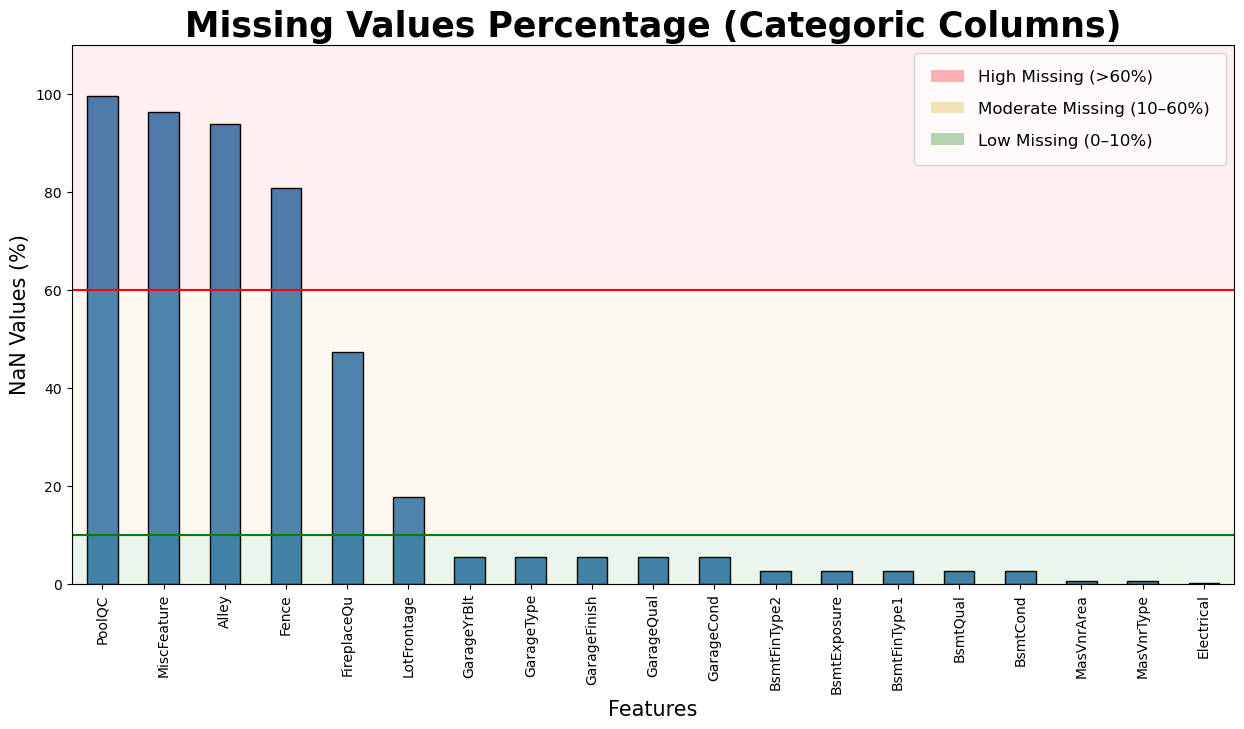

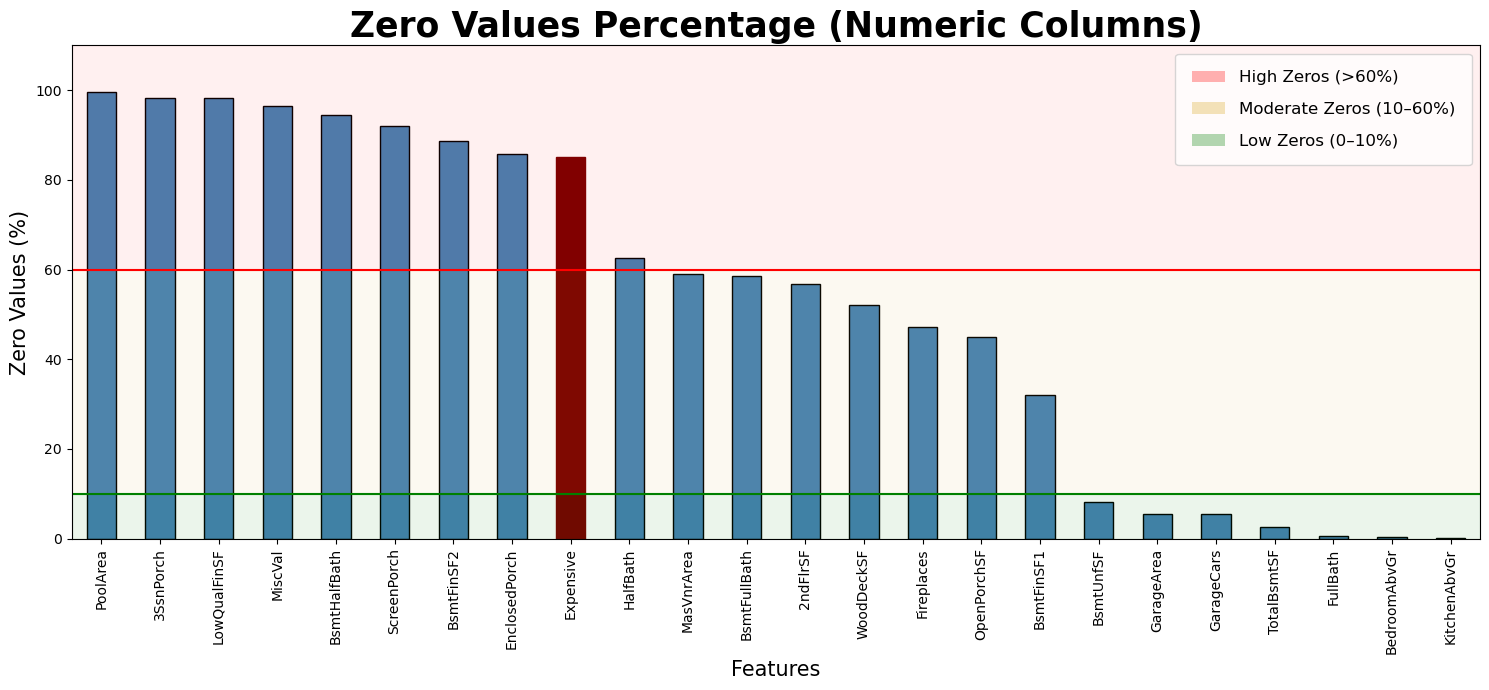

In [7]:
def missing_visual(df, color = "steelblue", edgecolor = "black", height = 7, width = 15):
    plt.figure(figsize=(width, height))
    persantage = (df.isnull().mean()) * 100
    ax = persantage[persantage > 0]\
        .sort_values(ascending=False)\
        .plot.bar(color=color, edgecolor=edgecolor, linewidth=1)

    plt.axhspan(0, 10, color='green', alpha=0.08)
    plt.axhspan(10, 60, color='goldenrod', alpha=0.06)
    ax.margins(y=0)
    ax.set_ylim(0, 110)
    plt.axhspan(60, ax.get_ylim()[1], color='red', alpha=0.06)

    plt.axhline(y = 10, color="green", linestyle = "-")
    #plt.axhline(y = 35, color="goldenrod", linestyle = "--")
    plt.axhline(y = 60, color="red", linestyle = "-")

    legend_elements = [
        Patch(facecolor='red', alpha=0.3, label='High Missing (>60%)'),
        Patch(facecolor='goldenrod', alpha=0.3, label='Moderate Missing (10–60%)'),
        Patch(facecolor='green', alpha=0.3, label='Low Missing (0–10%)')
    ]
    ax.legend(handles=legend_elements, 
              loc="upper right", 
              fontsize=12, 
              labelspacing=1, 
              frameon=True, 
              borderpad=1)

    plt.title("Missing Values Percentage (Categoric Columns)", fontsize=25, weight="bold")
    plt.xlabel("Features", fontsize=15)
    plt.ylabel("NaN Values (%)", fontsize=15)

    
    return plt.show()

def zero_visual(df, color="steelblue", edgecolor="black", height=7, width=15, threshold=0.0):
    num = df.select_dtypes(include="number")
    if num.shape[1] == 0:
        print("No numeric columns found.")
        return

    pct_zero = (num.eq(0).mean() * 100).sort_values(ascending=False)
    pct_zero = pct_zero[pct_zero > threshold]

    plt.figure(figsize=(width, height))
    ax = pct_zero.plot.bar(color=color, edgecolor=edgecolor, linewidth=1)
    ax.patches[8].set_color("#7A0000")

    plt.axhspan(0, 10, color='green', alpha=0.08)
    plt.axhspan(10, 60, color='goldenrod', alpha=0.06)
    ax.margins(y=0)
    ax.set_ylim(0, 110)
    plt.axhspan(60, ax.get_ylim()[1], color='red', alpha=0.06)

    plt.axhline(y=10, color="green", linestyle="-")
    plt.axhline(y=60, color="red", linestyle="-")

    legend_elements = [
        Patch(facecolor='red', alpha=0.3, label='High Zeros (>60%)'),
        Patch(facecolor='goldenrod', alpha=0.3, label='Moderate Zeros (10–60%)'),
        Patch(facecolor='green', alpha=0.3, label='Low Zeros (0–10%)')
    ]
    ax.legend(handles=legend_elements, loc="upper right", fontsize=12, labelspacing=1, frameon=True, borderpad=1)

    plt.title("Zero Values Percentage (Numeric Columns)", fontsize=25, weight="bold")
    plt.xlabel("Features", fontsize=15)
    plt.ylabel("Zero Values (%)", fontsize=15)
    plt.tight_layout()
    plt.show()


missing_visual(df)
zero_visual(df)


In [8]:
pd.crosstab(df["PoolQC"].isnull(), df["Expensive"], normalize="index")

Expensive,0,1
PoolQC,,
False,0.714286,0.285714
True,0.852030,0.147970


<Axes: xlabel='PoolArea', ylabel='Expensive'>

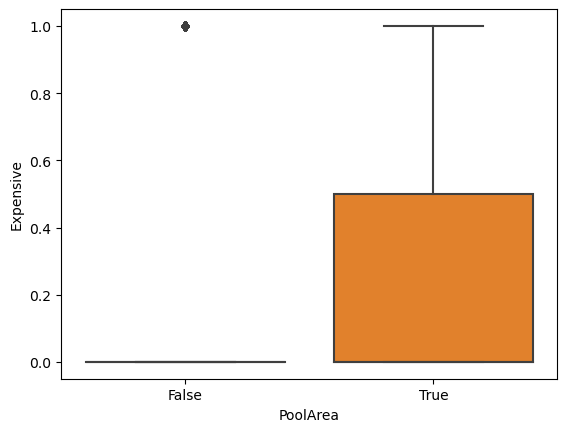

In [9]:
sns.boxplot(x=df["PoolArea"] > 0, y=df["Expensive"])

Check multicollinearity

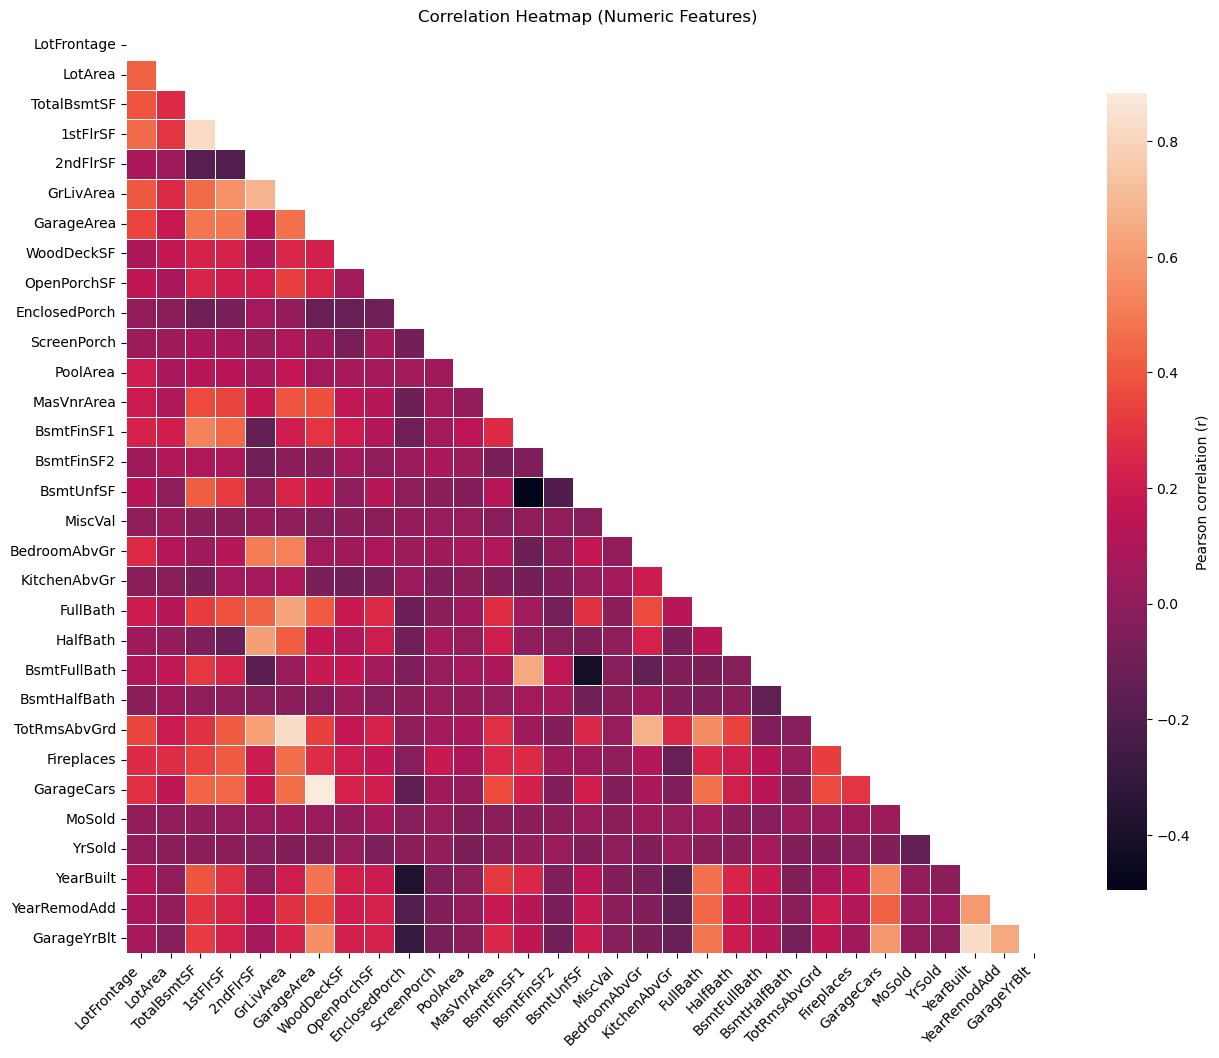

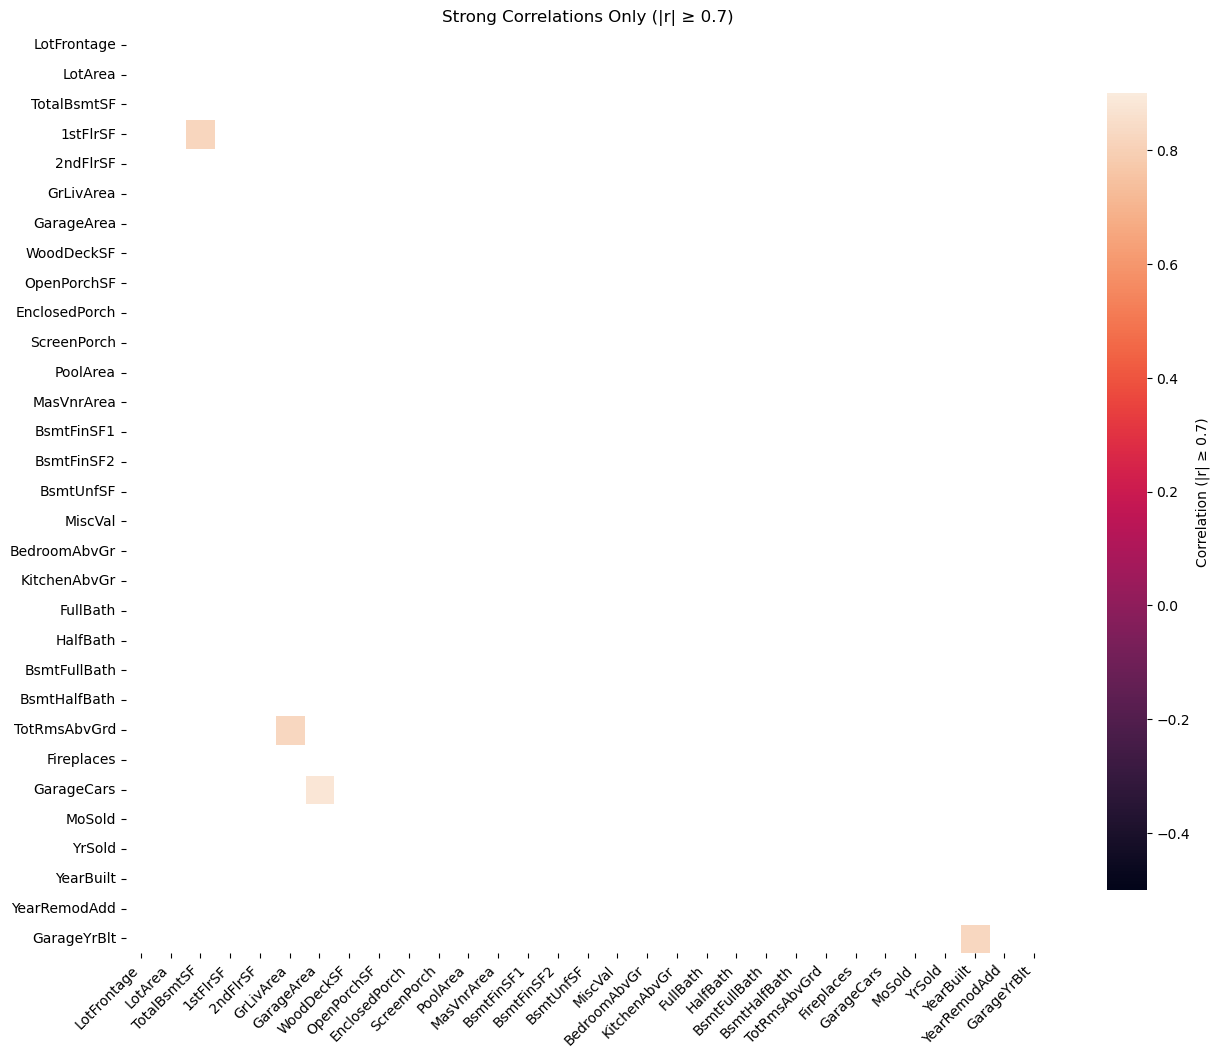

In [10]:
corr = df[numerical_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
threshold = 0.7

def pearson_correlation():
    plt.figure(figsize=(13,11))
    sns.heatmap(
        corr,
        mask=mask,
        linewidths=0.5,
        annot=False,
        square=True, 
        cbar_kws={"shrink": 0.8, "label": "Pearson correlation (r)"}
    )
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.title("Correlation Heatmap (Numeric Features)")
    plt.tight_layout()
    plt.show()

def strong_pearson_correlation():
    corr[(corr.abs() < threshold)] = np.nan
    plt.figure(figsize=(13, 11))
    sns.heatmap(
        corr,
        mask=mask,
        linewidths=0.5,
        vmin=-0.5, vmax=0.9,
        square=True,
        annot=False,
        cbar_kws={"shrink": 0.8, "label": f"Correlation (|r| ≥ {threshold})"}
    )
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.title(f"Strong Correlations Only (|r| ≥ {threshold})")
    plt.tight_layout()
    plt.show()

pearson_correlation()
strong_pearson_correlation()

The correlation heatmap (|r| ≥ 0.7) shows only a few strong correlations, 
primarily between structurally related variables such as GarageArea–GarageCars and YearBuilt–GarageYrBlt. 
These relationships are logically expected and do not indicate problematic redundancy.
Overall, no severe multicollinearity was detected, and the dataset is appropriate for Logistic Regression.
But we wil test more model types.

---

In [11]:
df.corr()["Expensive"].sort_values(ascending=False)

/var/folders/cb/nv527ffd4sn4f92077l2twqr0000gn/T/ipykernel_44191/104743523.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()["Expensive"].sort_values(ascending=False)


Expensive        1.000000
OverallQual      0.591136
GrLivArea        0.512482
GarageArea       0.476036
1stFlrSF         0.468795
TotalBsmtSF      0.467167
GarageCars       0.460152
TotRmsAbvGrd     0.388254
MasVnrArea       0.385162
FullBath         0.343958
Fireplaces       0.343523
YearRemodAdd     0.336155
YearBuilt        0.329442
GarageYrBlt      0.328413
BsmtFinSF1       0.315770
LotFrontage      0.269355
WoodDeckSF       0.259138
OpenPorchSF      0.251542
LotArea          0.207233
2ndFlrSF         0.204820
BsmtFullBath     0.199329
BsmtUnfSF        0.149911
HalfBath         0.145223
BedroomAbvGr     0.075514
ScreenPorch      0.069669
MoSold           0.059233
PoolArea         0.033286
3SsnPorch        0.011505
MiscVal         -0.012762
YrSold          -0.017430
Id              -0.027244
LowQualFinSF    -0.027581
BsmtFinSF2      -0.032944
BsmtHalfBath    -0.044249
EnclosedPorch   -0.076329
MSSubClass      -0.080218
OverallCond     -0.082821
KitchenAbvGr    -0.088351
Name: Expens

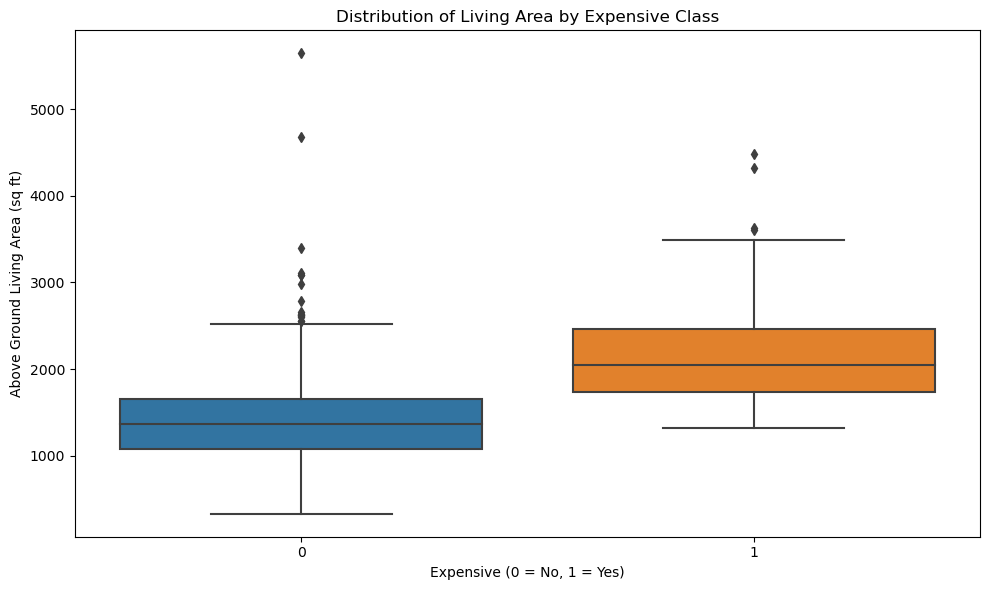

In [12]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x="Expensive", y="GrLivArea", data=df)

plt.title("Distribution of Living Area by Expensive Class")
plt.xlabel("Expensive (0 = No, 1 = Yes)")
plt.ylabel("Above Ground Living Area (sq ft)")
plt.tight_layout()
plt.show()

### Missing Values Interpritation

This graph devided into 3 regions:
1. Columns that not crossing `Green 10%` threshold NaN values can be replased with this teqniqes(median, knn, 0, or "None" depending on meaning)
2. Columns in yellow region cen be dropped but we hawe to make a research. Maybe missing values represents None or 0.
3. Those who crossed red line contain more than 60% missing values.  
    Due to the high proportion of missing data, these columns will be dropped from the analysis.

    However, not every house includes features such as **Pool**, **Alley**, or **Fence**.  
    In these cases, missing values do not represent data errors but rather the absence of those features.  
    Therefore, these variables will be replaced with `"None"` to indicate that the property does not have that amenity.

    But!

        According to housing statistics from RubyHome real estate source, 
        only about 8% of households in the United States have a swimming pool, 
        which corresponds to approximately 10.4 million residential swimming pools nationwide.
        
    This supports the decision to treat missing `Pool` values as absence rather than unknown data because only 0.48% housholders in data have `Pool`.


### Missing Values Interpretation

This graph is divided into three regions:

1. **Low Missing (0–10%) – Green Region**  
   Columns below the 10% threshold contain few missing values.  
   These can be imputed using appropriate techniques such as median imputation, KNN, `0`, or `"None"` depending on the feature meaning.

2. **Moderate Missing (10–60%) – Yellow Region**  
   Columns in this region require further research.  
   Missing values may represent meaningful absence (e.g., no garage or no fireplace) rather than true data gaps.  
   We should decide whether to impute, encode as `"None"`, or remove the feature.

3. **High Missing (>60%) – Red Region**  
   Columns above the 60% threshold contain a high proportion of missing values.  
   Due to the large amount of missing data, these features can be considered for removal. 
   Howewer not every house includes features such as **Pool**, **Alley**, or **Fence**.
   In these cases, missing values do not represent data errors but rather the absence of those amenities. 
   Therefore, these variables may be replaced with `"None"` to indicate that the property does not include that feature.
   We will test each feture.

##### Pool Feature Research

According to housing statistics from the RubyHome real estate source, only about **8% of households in the United States have a swimming pool**, 
corresponding to approximately **10.4 million residential swimming pools nationwide**.

In this dataset, only **0.48% of properties have a recorded pool**, which strongly suggests that missing `Pool` values represent the absence of a pool 
rather than unknown information.  
Therefore, we drop this feture.

In [13]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
X = df[numeric_cols].drop(columns=["Expensive"])  # remove target

In [14]:
X_const = sm.add_constant(X)
X_const.head(5)

,const,LotArea,LotFrontage,TotalBsmtSF,BedroomAbvGr,Fireplaces,PoolArea,GarageCars,WoodDeckSF,ScreenPorch,MSSubClass,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,KitchenAbvGr,TotRmsAbvGrd,GarageYrBlt,GarageArea,OpenPorchSF,EnclosedPorch,3SsnPorch,MiscVal,MoSold,YrSold,Id
0,1.0,8450,65.0,856,3,0,0,2,0,0,60,7,5,2003,2003,196.0,706,0,150,856,854,0,1710,1,0,2,1,1,8,2003.0,548,61,0,0,0,2,2008,1
1,1.0,9600,80.0,1262,3,1,0,2,298,0,20,6,8,1976,1976,0.0,978,0,284,1262,0,0,1262,0,1,2,0,1,6,1976.0,460,0,0,0,0,5,2007,2
2,1.0,11250,68.0,920,3,1,0,2,0,0,60,7,5,2001,2002,162.0,486,0,434,920,866,0,1786,1,0,2,1,1,6,2001.0,608,42,0,0,0,9,2008,3
3,1.0,9550,60.0,756,3,1,0,3,0,0,70,7,5,1915,1970,0.0,216,0,540,961,756,0,1717,1,0,1,0,1,7,1998.0,642,35,272,0,0,2,2006,4
4,1.0,14260,84.0,1145,4,1,0,3,192,0,60,8,5,2000,2000,350.0,655,0,490,1145,1053,0,2198,1,0,2,1,1,9,2000.0,836,84,0,0,0,12,2008,5


In [15]:
r, p = pointbiserialr(df['Expensive'], df['OverallQual'])

print(f"Correlation: {r:.4f}")
print(f"P-value: {p:.6f}")

Correlation: 0.5911
P-value: 0.000000


In [16]:
# ---- Target / features ----
TARGET_COL = "Expensive"
assert TARGET_COL in df.columns, f"Target column '{TARGET_COL}' not found in the dataset."

# ---- Columns to drop after permutation importance analysis ----
# 1. Drop them after first try: "BsmtFinType2", "GarageArea", "SaleType", "FireplaceQu", "BsmtCond", "GarageYrBlt"
# 2. Add them too after seckond run: "MasVnrArea", "GarageFinish", "YearBuilt"
# 3. Extra try: "LandContour", "MiscVal", "EnclosedPorch", "Functional", "BsmtHalfBath", "Exterior2nd", "Id", "OpenPorchSF", "OverallCond", "YrSold", "GarageType", "BsmtFinSF2"
# 4. one more: "Heating", "LotShape", "Electrical", "ExterQual", "GarageQual", "Condition1", "BsmtFinSF1", "3SsnPorch", "LotArea", "BldgType", "BsmtFinType1", "MasVnrType", "LotFrontage", "ExterCond", "TotRmsAbvGrd", "Foundation", "FullBath", "SaleCondition"


X = df.drop(columns=[TARGET_COL
                                    ])
y = df[TARGET_COL]

print("Class distribution (counts):")
print(y.value_counts())
print("\nClass distribution (percent):")
print((y.value_counts(normalize=True) * 100).round(2))


Class distribution (counts):
0    1243
1     217
Name: Expensive, dtype: int64

Class distribution (percent):
0    85.14
1    14.86
Name: Expensive, dtype: float64


## Train/Test Split
We keep a held-out **test set** for final evaluation only.  
We stratify to preserve the class ratio.


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (1168, 80) Test: (292, 80)


## Baseline
A baseline is mandatory. It answers: **do we beat a trivial strategy?**  
We start with a `DummyClassifier` that always predicts the most frequent class.


In [18]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix

dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
y_dummy = dummy.predict(X_test)

print("=== Dummy Baseline (most_frequent) ===")
print(classification_report(y_test, y_dummy, digits=3))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_dummy))


=== Dummy Baseline (most_frequent) ===
              precision    recall  f1-score   support

           0      0.853     1.000     0.921       249
           1      0.000     0.000     0.000        43

    accuracy                          0.853       292
   macro avg      0.426     0.500     0.460       292
weighted avg      0.727     0.853     0.785       292

Confusion matrix:
[[249   0]
 [ 43   0]]


/Users/roma/anaconda3/envs/deep_learning/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/roma/anaconda3/envs/deep_learning/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/roma/anaconda3/envs/deep_learning/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

## Preprocessing (leakage-safe)
We automatically detect:
- **Numeric features** → median imputation (+ scaling for distance/linear models)
- **Categorical features (if any)** → most-frequent imputation + one-hot encoding

> If the dataset contains only numeric features, the categorical branch is skipped.


In [19]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_features = X.select_dtypes(include=["number"]).columns.tolist()
cat_features = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Numeric features:", len(num_features), num_features)
print("Categorical features:", len(cat_features), cat_features)

def make_preprocessor(scale_numeric: bool):
    # numeric pipeline
    num_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        num_steps.append(("scaler", StandardScaler()))
    num_pipe = Pipeline(steps=num_steps)

    transformers = [("num", num_pipe, num_features)]
    if len(cat_features) > 0:
        cat_pipe = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ])
        transformers.append(("cat", cat_pipe, cat_features))

    return ColumnTransformer(transformers=transformers, remainder="drop")

# Trees don't need scaling; KNN/LogReg do.
preprocess_tree = make_preprocessor(scale_numeric=False)
preprocess_scaled = make_preprocessor(scale_numeric=True)


Numeric features: 37 ['LotArea', 'LotFrontage', 'TotalBsmtSF', 'BedroomAbvGr', 'Fireplaces', 'PoolArea', 'GarageCars', 'WoodDeckSF', 'ScreenPorch', 'MSSubClass', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'KitchenAbvGr', 'TotRmsAbvGrd', 'GarageYrBlt', 'GarageArea', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'MiscVal', 'MoSold', 'YrSold', 'Id']
Categorical features: 43 ['MSZoning', 'Condition1', 'Heating', 'Street', 'CentralAir', 'Foundation', 'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'KitchenQual', 'FireplaceQu', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'BsmtFinType2', 'HeatingQC', 'Electrical', 'Functional', 'G

## Evaluation strategy (metrics)
Because accuracy can hide poor minority-class performance, we use:
- **F1** for model selection (balances precision & recall)
- **ROC-AUC** (ranking quality across thresholds)
- **PR-AUC** (often more informative with class imbalance)

We also inspect confusion matrices to understand error types.


## Models and rationale
We compare complementary models:
1. **Logistic Regression** — strong, interpretable baseline
2. **Decision Tree** — captures non-linear rules
3. **KNN** — local similarity; sensitive to scaling (handled above)

We tune Tree and KNN with cross-validation. We tune `C` for Logistic Regression.


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

pipe_logreg = Pipeline(steps=[
    ("prep", preprocess_scaled),
    ("model", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))
])

pipe_tree = Pipeline(steps=[
    ("prep", preprocess_tree),
    ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
])

pipe_knn = Pipeline(steps=[
    ("prep", preprocess_scaled),
    ("model", KNeighborsClassifier())
])


In [21]:
pipe_logreg

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Cross-validation + hyperparameter tuning
We use stratified CV to preserve class balance in each fold.


In [22]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_tree = {
    "model__max_depth": [2, 3, 5, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 5, 10],
}

grid_knn = {
    "model__n_neighbors": [3, 5, 7, 11, 15],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2],  # Manhattan vs Euclidean
}

grid_logreg = {
    "model__C": [0.1, 1, 10]
}

search_tree = GridSearchCV(pipe_tree, param_grid=grid_tree, scoring="f1", cv=cv, n_jobs=-1)
search_knn  = GridSearchCV(pipe_knn,  param_grid=grid_knn,  scoring="f1", cv=cv, n_jobs=-1)
search_logreg = GridSearchCV(pipe_logreg, param_grid=grid_logreg, scoring="f1", cv=cv, n_jobs=-1)

search_tree.fit(X_train, y_train)
search_knn.fit(X_train, y_train)
search_logreg.fit(X_train, y_train)

print("Best Tree params:", search_tree.best_params_)
print("Best Tree CV F1 :", round(search_tree.best_score_, 3))

print("\nBest KNN params:", search_knn.best_params_)
print("Best KNN CV F1 :", round(search_knn.best_score_, 3))

print("\nBest LogReg params:", search_logreg.best_params_)
print("Best LogReg CV F1 :", round(search_logreg.best_score_, 3))


Best Tree params: {'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5}
Best Tree CV F1 : 0.767

Best KNN params: {'model__n_neighbors': 3, 'model__p': 1, 'model__weights': 'uniform'}
Best KNN CV F1 : 0.745

Best LogReg params: {'model__C': 1}
Best LogReg CV F1 : 0.832


## Test set evaluation
We now evaluate the best estimators on the held-out test set.


In [23]:
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix

def evaluate(model, name):
    y_pred = model.predict(X_test)

    roc = pr = None
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, y_proba)
        pr  = average_precision_score(y_test, y_proba)

    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, digits=3))
    print("Confusion matrix:")
    print(confusion_matrix(y_test, y_pred))
    if roc is not None:
        print(f"ROC-AUC: {roc:.3f}")
        print(f"PR-AUC : {pr:.3f}")

best_tree   = search_tree.best_estimator_
best_knn    = search_knn.best_estimator_
best_logreg = search_logreg.best_estimator_

evaluate(dummy, "Dummy Baseline")
evaluate(best_logreg, "LogReg (tuned)")
evaluate(best_tree,   "Decision Tree (tuned)")
evaluate(best_knn,    "KNN (tuned)")



=== Dummy Baseline ===
              precision    recall  f1-score   support

           0      0.853     1.000     0.921       249
           1      0.000     0.000     0.000        43

    accuracy                          0.853       292
   macro avg      0.426     0.500     0.460       292
weighted avg      0.727     0.853     0.785       292

Confusion matrix:
[[249   0]
 [ 43   0]]
ROC-AUC: 0.500
PR-AUC : 0.147

=== LogReg (tuned) ===
              precision    recall  f1-score   support

           0      0.964     0.976     0.970       249
           1      0.850     0.791     0.819        43

    accuracy                          0.949       292
   macro avg      0.907     0.883     0.895       292
weighted avg      0.947     0.949     0.948       292

Confusion matrix:
[[243   6]
 [  9  34]]
ROC-AUC: 0.981
PR-AUC : 0.870

=== Decision Tree (tuned) ===
              precision    recall  f1-score   support

           0      0.952     0.948     0.950       249
           1    

/Users/roma/anaconda3/envs/deep_learning/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/roma/anaconda3/envs/deep_learning/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/roma/anaconda3/envs/deep_learning/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod


=== KNN (tuned) ===
              precision    recall  f1-score   support

           0      0.960     0.976     0.968       249
           1      0.846     0.767     0.805        43

    accuracy                          0.945       292
   macro avg      0.903     0.872     0.887       292
weighted avg      0.944     0.945     0.944       292

Confusion matrix:
[[243   6]
 [ 10  33]]
ROC-AUC: 0.941
PR-AUC : 0.816


## Model comparison (interpretation)
After reviewing test performance:
- **LogReg** indicates how much signal is available in roughly linear form.
- **Tree** often wins when there are non-linear interactions (e.g., “size + amenity” rules).
- **KNN** can perform well but is less interpretable and more sensitive to noise.

In professional settings, we typically prefer the model that offers the best trade-off between:
- performance on the expensive class (recall/F1),
- stability,
- interpretability.


## Threshold tuning (methodologically clean)
Default threshold is 0.5. If false negatives are costly, we may prefer a different threshold.

To avoid optimistic bias, we **choose the threshold on a validation split** from the training data,
then report its performance on the held-out test set.


In [24]:
from sklearn.metrics import precision_recall_curve, f1_score

# Validation split from training data
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.25,
    stratify=y_train,
    random_state=RANDOM_STATE
)

def choose_threshold_by_f1(model, X_val, y_val):
    proba = model.predict_proba(X_val)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_val, proba)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-12)
    best_idx = np.argmax(f1)
    thr = thresholds[max(best_idx - 1, 0)]
    return float(thr), float(f1[best_idx])

def report_threshold_on_test(model, thr, name):
    proba_test = model.predict_proba(X_test)[:, 1]
    y_pred_thr = (proba_test >= thr).astype(int)
    print(f"{name}: threshold={thr:.3f} | Test F1={f1_score(y_test, y_pred_thr):.3f}")

# Refit selected final model candidates on X_tr for threshold selection
dummy.fit(X_tr, y_tr)
best_tree.fit(X_tr, y_tr)
best_knn.fit(X_tr, y_tr)
best_logreg.fit(X_tr, y_tr)

for mdl, name in [(dummy, "Dummy Baseline"), (best_logreg, "LogReg tuned"), (best_tree, "Tree tuned"), (best_knn, "KNN tuned")]:
    thr, best_val_f1 = choose_threshold_by_f1(mdl, X_val, y_val)
    print(f"{name}: best validation F1={best_val_f1:.3f} at threshold={thr:.3f}")
    report_threshold_on_test(mdl, thr, name)


Dummy Baseline: best validation F1=0.257 at threshold=0.000
Dummy Baseline: threshold=0.000 | Test F1=0.257
LogReg tuned: best validation F1=0.918 at threshold=0.355
LogReg tuned: threshold=0.355 | Test F1=0.851
Tree tuned: best validation F1=0.742 at threshold=0.071
Tree tuned: threshold=0.071 | Test F1=0.631
KNN tuned: best validation F1=0.812 at threshold=0.000
KNN tuned: threshold=0.000 | Test F1=0.257


## Error analysis
We inspect misclassifications to understand *where* the model fails.  


In [25]:
def error_analysis(model, model_name):
    errors = X_test.copy()
    errors["y_true"] = y_test.values
    errors["y_pred"] = model.predict(X_test)

    mistakes = errors[errors["y_true"] != errors["y_pred"]]
    false_negatives = errors[(errors["y_true"] == 1) & (errors["y_pred"] == 0)]
    false_positives = errors[(errors["y_true"] == 0) & (errors["y_pred"] == 1)]

    print(f"\n=== {model_name} ===")
    print(f"Total test rows: {len(errors)}")
    print(f"Mistakes: {len(mistakes)}")
    print(f"False negatives (costly): {len(false_negatives)}")
    print(f"False positives: {len(false_positives)}")

    display(mistakes[["y_true", "y_pred"]].head(5))

error_analysis(best_logreg, "Logistic Regression (tuned)")
error_analysis(best_tree,   "Decision Tree (tuned)")
error_analysis(best_knn,    "KNN (tuned)")


=== Logistic Regression (tuned) ===
Total test rows: 292
Mistakes: 14
False negatives (costly): 9
False positives: 5


,y_true,y_pred
523,0,1
1375,0,1
158,1,0
539,1,0
451,1,0



=== Decision Tree (tuned) ===
Total test rows: 292
Mistakes: 20
False negatives (costly): 11
False positives: 9


,y_true,y_pred
112,1,0
523,0,1
400,0,1
1349,0,1
158,1,0



=== KNN (tuned) ===
Total test rows: 292
Mistakes: 18
False negatives (costly): 11
False positives: 7


,y_true,y_pred
523,0,1
1375,0,1
283,0,1
400,0,1
1060,0,1


## Interpretability: permutation importance
Permutation importance estimates how much each feature contributes to model performance.
It is model-agnostic and works well with pipelines.


In [26]:
from sklearn.inspection import permutation_importance
final_model = best_logreg

def get_permutation_importance(model, model_name, X_test, y_test):

    perm = permutation_importance(
        model,
        X_test, y_test,
        n_repeats=30,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    importances = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)
    print(f"\n === {model_name} ===")
    display(importances)

# Dummy doesn't have predict_proba, so we skip it for permutation importance.
# get_permutation_importance(dummy, "Dummy Baseline", X_test, y_test) 
get_permutation_importance(best_logreg, "Logistic Regression (tuned)", X_test, y_test)
#get_permutation_importance(best_tree,   "Decision Tree (tuned)", X_test, y_test)
#get_permutation_importance(best_knn,    "KNN (tuned)", X_test, y_test)


 === Logistic Regression (tuned) ===


OverallQual      2.031963e-02
GrLivArea        1.289954e-02
2ndFlrSF         6.278539e-03
SaleType         2.511416e-03
BsmtFullBath     2.283105e-03
YearRemodAdd     1.598174e-03
BedroomAbvGr     1.484018e-03
KitchenQual      1.369863e-03
TotalBsmtSF      1.141553e-03
1stFlrSF         1.141553e-03
BsmtExposure     9.132420e-04
KitchenAbvGr     7.990868e-04
LowQualFinSF     5.707763e-04
Fireplaces       4.566210e-04
BsmtFinType1     4.566210e-04
BsmtFinSF1       3.424658e-04
Exterior1st      3.424658e-04
BsmtQual         2.283105e-04
RoofStyle        2.283105e-04
ScreenPorch      2.283105e-04
HeatingQC        2.283105e-04
WoodDeckSF       1.141553e-04
LandSlope        1.141553e-04
OpenPorchSF      1.141553e-04
Heating          1.141553e-04
MSZoning         1.141553e-04
SaleCondition    3.700743e-18
LandContour      0.000000e+00
GarageArea       0.000000e+00
BldgType         0.000000e+00
Condition2       0.000000e+00
CentralAir       0.000000e+00
Electrical       0.000000e+00
Utilities 

## Summary & Conclusion

### Project Summary
This project gives a binary classification task: identifying whether a residential property belongs to the **expensive segment** = 1 or **not expensive** = 0.

We uses methods for the analysis, including:
- clear problem framing with attention to decision costs,
- leakage-safe preprocessing using pipelines,
- strong baselines (DummyClassifier),
- cross-validated model tuning,
- evaluation on a held-out test set,
- detailed error analysis focused on costly mistakes,
- and model interpretability using permutation importance.

Several models were evaluated (Logistic Regression, Decision Tree, and KNN) to compare different assumptions about the data.

---

### 🏆 Final Model Selection
**Final model: Logistic Regression (tuned)**

Logistic Regression was selected because:

- It makes the **fewest costly errors**
  - 9 false negatives vs 10 (Decision Tree) vs 11 (KNN)
- It has the **lowest total number of mistakes**
  - 14 vs 17 (KNN) vs 23 (Decision Tree)
- Its predictions are **conservative and stable**, avoiding aggressive over-classification.

Although non-linear models achieved competitive cross-validated scores, error analysis shows that Logistic Regression produse less errors.

---

### 🔒Limitations
- The dataset is compact and does not include neighbourhood-level or temporal features that are often predictive of property value.
- The binary target simplifies a continuous price spectrum, adding real prises can make our prediction more accurate.

---

### Next Steps
Potential future improvements include:
- probability calibration to improve reliability of predicted scores,
- comparison with other models (e.g. Random Forest) to see if improvement is possible.

---

### ✍Final Note
This analysis shows the importance of selecting models based on **decision costs and error behaviour**, not only on aggregate metrics or model complexity.  
The chosen model prioritises reliability, interpretability, and decision safety, which are essential in real-world data science applications.